In [ ]:
#| hide
# BASED ON
  # Kalman filtering and smoothing-3_ANNO^V5.ipynb
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# split into 3 pars
# clean
# v6 starts ------------------------------------------------
# migrate to cursor & github
# change s --> x (for state)
# tildes --> * for true quantities
# switch roles of A & B back again to eng convention, but B --> C
# remove all underscores indicating globals
# add underscores for bold symbols which have spatial structure

# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


In [1]:
versioninfo() ##. Julia version

Julia Version 1.10.5
Commit 6f3fdf7b362 (2024-08-27 14:19 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)


In [2]:
# Activate local environment, see `Project.toml`
# import Pkg; Pkg.activate(".."); Pkg.instantiate();
import Pkg
Pkg.add("BenchmarkTools")

using RxInfer, BenchmarkTools, Random, LinearAlgebra, Plots, LaTeXStrings, Distributions, StableRNGs

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [3]:
Pkg.status()

Status `~/.julia/environments/v1.10/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [31c24e10] Distributions v0.25.131
  [7073ff75] IJulia v1.34.4
  [b964fa9f] LaTeXStrings v1.4.1
  [91a5bcdd] Plots v1.41.7
  [86711068] RxInfer v5.5.2
  [860ef19b] StableRNGs v1.0.4


# Kalman filtering and smoothing

In the following set of examples the goal is to estimate hidden <u>states</u> of a Dynamical process where all hidden states are Gaussians.

We start our journey with a simple 

- (1) multivariate Linear Gaussian State Space Model (LGSSM), which can be solved analytically. We then solve an 
- (2) identification problem which does not have an analytical solution. Utimately, we show how **RxInfer.jl** can 
- (3) deal with missing observations.

# 3 Handling Missing Data

An interesting case in filtering and smoothing problems is the processing of missing data. It can happen that sometimes your reading devices fail to acquire the data leading to missing observation.

Let us assume that the following model generates the data

$$\begin{aligned}
    {x}_t &\sim \mathcal{N}\left({x}_{t-1}, w\right) \\
    {y}_t &\sim \mathcal{N}\left({x}_{t}, v \right) 
\end{aligned}$$
where $w = 1.0$

with prior ${x}_0 \sim \mathcal{N}({m_{{x}_0}}, {v_{{x}_0}})$. Suppose that our measurement device fails to acquire data from time to time.  In this case, instead of scalar observation $y_t \in \mathcal{R}$ we sometimes will catch `missing` observations.

In [9]:
μᵥᵥ = 0.0
σ²ᵥᵥ = 0.1

μᵥ = 0.0
σ²ᵥ = 1.0
T = 250
missing_indices = 100:125

100:125

## The Generative Process

### Provision function ($f_p$)
The *provision* function, provides another covariate vector. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function:

$$p^*_{t} = f_{p}(t) = t$$
$$s^*_{t} = f_{p}(t) + w = p^*_{t} + w$$

where

$w \sim \mathcal{N}(\mu_W, \sigma^2_W)$

The `*`s indicate that the parameters and variables are hidden and not observed.

In [10]:
## provision function, provides next batch of covariate vectors
## covariate vector here is just a scalar
function fₚ(;T)
    ## tmp = float.(collect(1:N))
    ## return [[i] for i in tmp]
    pˣₜ = float.(collect(1:T))
    return pˣₜ
end
mypˣₜ = fₚ(T=5)

5-element Vector{Float64}:
 1.0
 2.0
 3.0
 4.0
 5.0

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector.
$$r^*_{t} = f_{r}(x^*_{t}) = \mathrm{sin}(0.05t)$$
$$y_{t} = f_{r}(x^*_{t}) + v = r^*_{t} + v$$
where

$v \sim \mathcal{N}(\mu_V, \sigma^2_V)$

The `*`s indicate that the parameters and variables are hidden and not observed.

In [11]:
## response function, provides next batch of responses to covariate vectors
## covariate vector here is just a scalar
function fᵣ(xˣ)
    rˣₜ = sin.(0.05*xˣ)
    return rˣₜ
end
fᵣ(mypˣₜ)

5-element Vector{Float64}:
 0.04997916927067833
 0.09983341664682815
 0.14943813247359924
 0.19866933079506122
 0.24740395925452294

In [12]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
function sim_batch_data(T; seed=123, μᵥᵥ, σ²ᵥᵥ, μᵥ, σ²ᵥ) ## simulated batch data
    rng = StableRNG(seed)
    pˣₜ = fₚ(T=T)
    w = rand(Normal(μᵥᵥ, sqrt(σ²ᵥᵥ)), T)
    xˣₜ = pˣₜ + w

    rˣₜ = fᵣ(xˣₜ)
    v = rand(Normal(μᵥ, sqrt(σ²ᵥ)), T)
    yₜ = rˣₜ + v

    yₜ_missing    = similar(yₜ, Union{Float64, Missing}, )
    copyto!(yₜ_missing, yₜ)
    for index in missing_indices
        yₜ_missing[index] = missing
    end
    return pˣₜ, xˣₜ, rˣₜ, yₜ, yₜ_missing
end

sim_batch_data (generic function with 1 method)

In [17]:
pˣₜ, xˣₜ_seq, rˣₜ, yₜ_seq, yₜ_missing = sim_batch_data(
    T; 
    μᵥᵥ=μᵥᵥ, σ²ᵥᵥ=σ²ᵥᵥ, 
    μᵥ=μᵥ, σ²ᵥ=σ²ᵥ);

In [18]:
xˣₜ_seq

250-element Vector{Float64}:
   0.2989545696048618
   1.9433849768046842
   2.7788594867716583
   4.529594450944046
   5.073595509285304
   6.076991954130131
   7.572682752451801
   7.864133486113457
   9.653405578100692
   9.674939016616134
  11.200677648388172
  12.367993751587086
  13.130954991356603
   ⋮
 238.89712699234505
 239.6403796056639
 241.260706802737
 241.43439234007826
 242.4791421406917
 244.09588950605928
 245.4625360247573
 246.0200691911113
 246.49549076528533
 247.53096633758025
 248.88391855185372
 249.3915328916459

In [20]:
yₜ_seq

250-element Vector{Float64}:
  1.5781586971922985
 -0.6516289786436376
  0.1927126900605198
  0.06470017074156137
 -1.1690698762840483
 -2.2870874635136227
  1.2161236602054712
  0.17583915856354085
  1.6298554557514005
  1.4367202151944114
  0.2994408776551341
 -0.1707896183502452
  2.3087469210543388
  ⋮
 -1.7420678777013414
 -0.9731058512034252
 -2.17849176767331
  0.0607062523703108
 -0.9110271516352819
 -1.016787205318087
 -2.729986871992518
  1.1012225999232628
  0.6680842689421533
 -0.9001165966673567
  1.1481287432013616
 -0.890951558883202

In [21]:
xˣₜ_seq

250-element Vector{Float64}:
   0.2989545696048618
   1.9433849768046842
   2.7788594867716583
   4.529594450944046
   5.073595509285304
   6.076991954130131
   7.572682752451801
   7.864133486113457
   9.653405578100692
   9.674939016616134
  11.200677648388172
  12.367993751587086
  13.130954991356603
   ⋮
 238.89712699234505
 239.6403796056639
 241.260706802737
 241.43439234007826
 242.4791421406917
 244.09588950605928
 245.4625360247573
 246.0200691911113
 246.49549076528533
 247.53096633758025
 248.88391855185372
 249.3915328916459

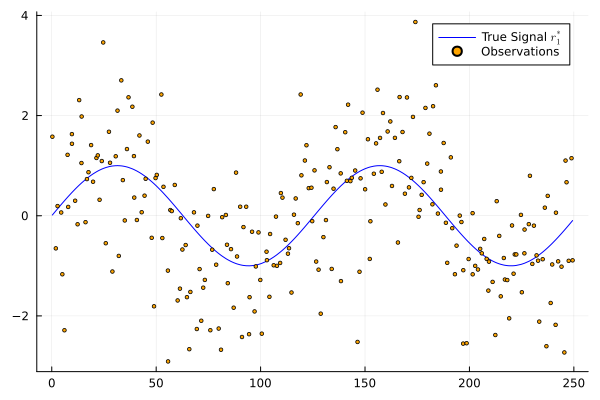

In [23]:
p = plot()
p = plot(p, xˣₜ_seq, rˣₜ, label="True Signal " * L"r^*_1", color=:blue)
p = scatter!(p, xˣₜ_seq, yₜ_seq, label="Observations", markersize=2, color=:orange)
plot(p)

## The Generative Model

In [24]:
@model function smoothing(y_seq, x₀)
    v ~ Gamma(shape=0.001, scale=0.001)
    x_prior ~ Normal(mean=mean(x₀), var=var(x₀))
    local x
    xₜ₋₁ = x_prior
    for t in 1:length(y_seq)
        x_seq[t] ~ Normal(mean=xₜ₋₁, precision=1.0)
        y_seq[t] ~ Normal(mean=x_seq[t], precision=v)
        xₜ₋₁ = x_seq[t]
    end
end

In [27]:
constraints = @constraints begin
    q(x_prior, x_seq, y_seq, v) = q(x_prior, x_seq)q(v)q(y_seq)
end

Constraints: 
  q(x_prior, x_seq, y_seq, v) = q(x_prior, x_seq)q(v)q(y_seq)


In [29]:
x₀_prior = NormalMeanVariance(0.0, 1000.0)
initm = @initialization begin
    q(v) = Gamma(0.001, 0.001)
end

result = infer(
    model = smoothing(x₀=x₀_prior), 
    data  = (y_seq = yₜ_missing,), 
    constraints = constraints,
    initialization = initm, 
    returnvars = (x_seq = KeepLast(),),
    iterations = 20
);

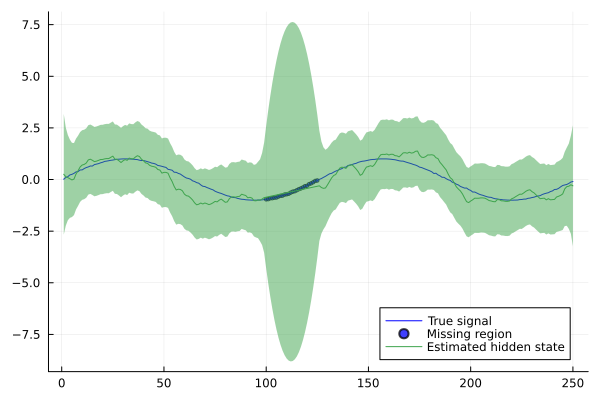

In [31]:
plot(rˣₜ, label="True signal", legend=:bottomright, color=:blue)
scatter!(
    missing_indices, 
    ## _p̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    ## _s̃ₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    rˣₜ[missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
    ## _yₜ[_missing_indices], ms=2, opacity=0.75, label="Missing region", color=:blue)
plot!(
    mean.(result.posteriors[:x_seq]), 
    ribbon=var.(result.posteriors[:x_seq]), label="Estimated hidden state")